In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings
from tqdm import tqdm

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

## Example with 2 clients

### Generate BN and clients

In [2]:
# Create a baseline model
set_seed()
bn_base = gum.fastBN(f"X<-Y->W->Z; X->Z")

# Generate clients
clients = {}
E, N = 2, 100
for e in range(E):

    # Init the client
    p = 0 if e == 0 else 0.2
    gt, mask = resample_bn_params(bn_base, prob=p)
    client = Client(gt, mask)

    # Generate data
    client.generate_data(size=N)

    # Learn the BN
    client.learn_bn()

    # Learn CNs
    client.learn_cn(ess=1)

    # Collect
    clients[e] = client

In [3]:
for e in range(E):
    print(f"Client {e}:\n")
    gnb.showCPTs(clients[e].gt)

Client 0:



Client 1:



### Plot updates

In [4]:
# Choose client
client_num = 0
client = clients[client_num]

# Set prior(s)
prior_clients_dict = clients.copy()
prior_clients_dict.pop(client_num)
prior_clients = list(prior_clients_dict.values())

# Update the client's prior CN
args = ["ConvComb", "unif"]
assert client.prior_cn.is_vacuous_all()
client.prior_cn.compute(prior_clients, *args)
assert not client.prior_cn.is_vacuous_any()

# Run mosaic
client.mosaic_cn()

In [5]:
def plot_cset(bn_min_max: tuple, var: str, parents_idx: int, ax, kwargs: dict = {}):

    # Extract the CPT
    bn_min, bn_max = bn_min_max
    cpt_min, cpt_max = get_tabular_cpt(bn_min.cpt(var)), get_tabular_cpt(
        bn_max.cpt(var)
    )

    # Extract the row corresp. to `parents`
    row = [cpt_min[parents_idx, :], cpt_max[parents_idx, :]]

    # Plot
    ax.plot([row[0][0], row[1][0]], [row[1][1], row[0][1]], **kwargs)


def plot_point(bn: gum.BayesNet, var: str, parents_idx: int, ax, kwargs: dict = {}):

    # Extract the info
    cpt = get_tabular_cpt(bn.cpt(var))
    row = cpt[parents_idx, :]

    # Plot
    ax.scatter(row[0], row[1], **kwargs)

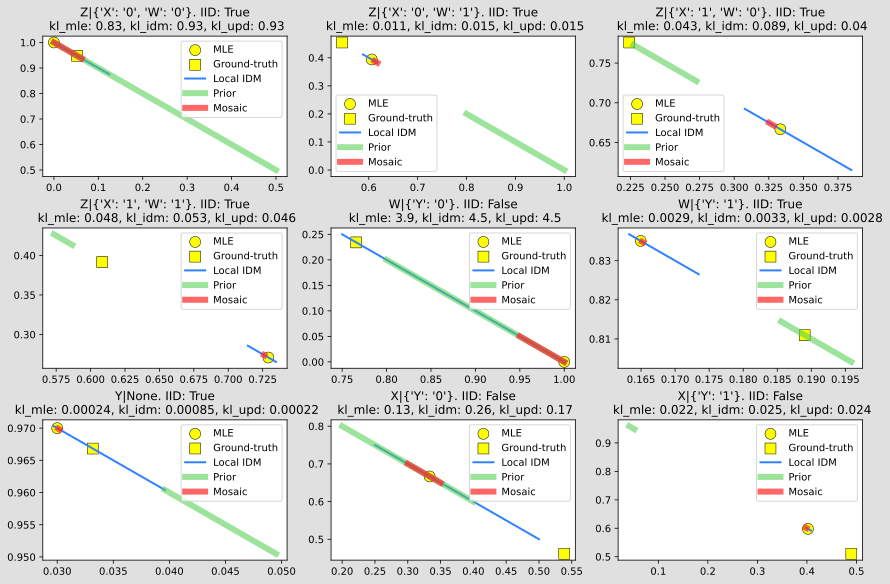

In [6]:
fig, axs = plt.subplots(3, 3, figsize=(12, 8), constrained_layout=True)
axs_flat = axs.flatten()

# Retrieve the models
bn = client.bn
gt = client.gt
idm = client.cn.get()
prior = client.prior_cn.get()
mosaic = client.cn_mosaic.get()

ax_idx = 0
for var in bn.names():

    # Get the mask CPT
    mask = client.prior_cn.get_mask(var)

    # For every parent configuration ...
    index_df = bn.cpt(var).topandas().index.to_frame(index=False)
    parents_conf = (
        [dict(index_df.iloc[i]) for i in range(len(index_df))]
        if len(bn.parents(var)) != 0
        else [None]
    )
    for parents in parents_conf:

        parents_idx = get_cpt_index(bn, var, parents)

        # Plot
        ax = axs_flat[ax_idx]
        ax_idx += 1

        plot_point(
            bn,
            var,
            parents_idx,
            ax,
            {
                "marker": "o",
                "s": 120,
                "linewidths": 0.5,
                "color": "#ffff00",
                "edgecolors": "black",
                "label": "MLE",
            },
        )
        plot_point(
            gt,
            var,
            parents_idx,
            ax,
            {
                "marker": "s",
                "s": 120,
                "linewidths": 0.5,
                "color": "#ffff00",
                "edgecolors": "black",
                "label": "Ground-truth",
            },
        )
        plot_cset(
            idm,
            var,
            parents_idx,
            ax,
            {
                "linestyle": "-",
                "color": "#2f82ff",
                "linewidth": 2,
                "label": "Local IDM",
            },
        )
        plot_cset(
            prior,
            var,
            parents_idx,
            ax,
            {"linestyle": "-", "color": "#52CF5292", "linewidth": 6, "label": "Prior"},
        )
        plot_cset(
            mosaic,
            var,
            parents_idx,
            ax,
            {"linestyle": "-", "color": "#ff2525b3", "linewidth": 6, "label": "Mosaic"},
        )

        # Get whether the prior is IID w.r.t. the current distribution

        are_iid = False if np.any(mask[parents_idx, :] == 0) else True

        # Compute KL divergences
        kl_mle = get_kl(client, var, parents)
        kl_idm = get_kl_cset(client, var, parents, idm)
        kl_upd = get_kl_cset(client, var, parents, mosaic)

        ax.legend()
        ax.set_title(
            f"{var}|{parents}. IID: {are_iid}\n kl_mle: {kl_mle:.2g}, kl_idm: {kl_idm:.2g}, kl_upd: {kl_upd:.2g}"
        )

## Example: many IID clients

### Generate BN and clients

In [7]:
# Create a baseline model
set_seed()
bn_base = gum.fastBN(f"X<-Y->W->Z; X->Z")

# Generate clients
clients = {}
E, N = 10, 100
p = 0
for e in range(E):

    # Init the client
    gt, mask = resample_bn_params(bn_base, prob=p)
    client = Client(gt, mask)

    # Generate data
    client.generate_data(size=N)

    # Learn the BN
    client.learn_bn()

    # Learn CNs
    client.learn_cn(ess=1)

    # Collect
    clients[e] = client

### Plot updates

In [8]:
# Choose client
client_num = 0
client = clients[client_num]

# Set prior(s)
prior_clients_dict = clients.copy()
prior_clients_dict.pop(client_num)
prior_clients = list(prior_clients_dict.values())

# Update the client's prior CN
args = ["ConvComb", "unif"]
assert client.prior_cn.is_vacuous_all()
client.prior_cn.compute(prior_clients, *args)
assert not client.prior_cn.is_vacuous_any()

# Run mosaic
client.mosaic_cn()

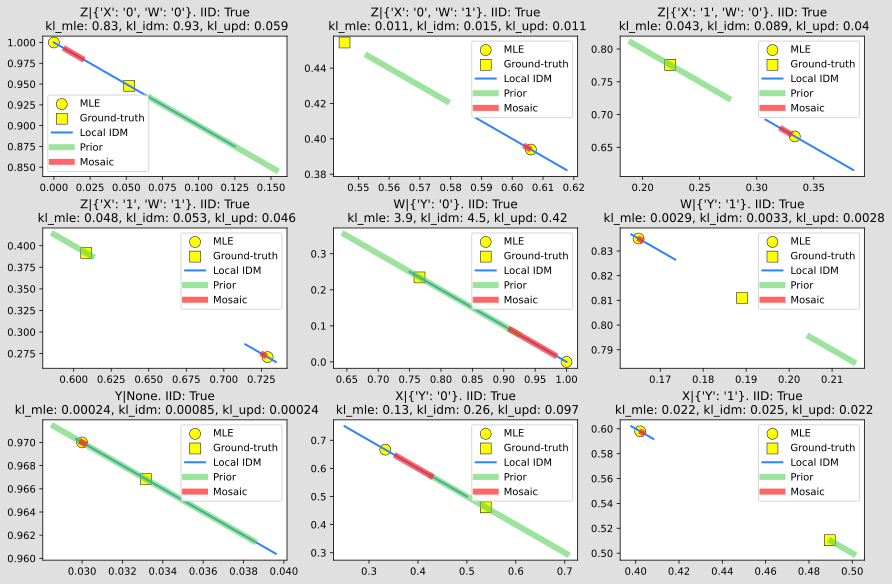

In [9]:
fig, axs = plt.subplots(3, 3, figsize=(12, 8), constrained_layout=True)
axs_flat = axs.flatten()

# Retrieve the models
bn = client.bn
gt = client.gt
idm = client.cn.get()
prior = client.prior_cn.get()
mosaic = client.cn_mosaic.get()

ax_idx = 0
for var in bn.names():

    # Get the mask CPT
    mask = client.prior_cn.get_mask(var)

    # For every parent configuration ...
    index_df = bn.cpt(var).topandas().index.to_frame(index=False)
    parents_conf = (
        [dict(index_df.iloc[i]) for i in range(len(index_df))]
        if len(bn.parents(var)) != 0
        else [None]
    )
    for parents in parents_conf:

        parents_idx = get_cpt_index(bn, var, parents)

        # Plot
        ax = axs_flat[ax_idx]
        ax_idx += 1

        plot_point(
            bn,
            var,
            parents_idx,
            ax,
            {
                "marker": "o",
                "s": 120,
                "linewidths": 0.5,
                "color": "#ffff00",
                "edgecolors": "black",
                "label": "MLE",
            },
        )
        plot_point(
            gt,
            var,
            parents_idx,
            ax,
            {
                "marker": "s",
                "s": 120,
                "linewidths": 0.5,
                "color": "#ffff00",
                "edgecolors": "black",
                "label": "Ground-truth",
            },
        )
        plot_cset(
            idm,
            var,
            parents_idx,
            ax,
            {
                "linestyle": "-",
                "color": "#2f82ff",
                "linewidth": 2,
                "label": "Local IDM",
            },
        )
        plot_cset(
            prior,
            var,
            parents_idx,
            ax,
            {"linestyle": "-", "color": "#52CF5292", "linewidth": 6, "label": "Prior"},
        )
        plot_cset(
            mosaic,
            var,
            parents_idx,
            ax,
            {"linestyle": "-", "color": "#ff2525b3", "linewidth": 6, "label": "Mosaic"},
        )

        # Get whether the prior is IID w.r.t. the current distribution
        are_iid = False if np.any(mask[parents_idx, :] == 0) else True

        # Compute KL divergences
        kl_mle = get_kl(client, var, parents)
        kl_idm = get_kl_cset(client, var, parents, idm)
        kl_upd = get_kl_cset(client, var, parents, mosaic)

        ax.legend()
        ax.set_title(
            f"{var}|{parents}. IID: {are_iid}\n kl_mle: {kl_mle:.2g}, kl_idm: {kl_idm:.2g}, kl_upd: {kl_upd:.2g}"
        )

## Example: many IID clients, varying sample sizes

In [10]:
# Create a baseline model
set_seed()
bn_base = gum.fastBN(f"X<-Y->W->Z; X->Z")

# Generate clients
clients = {}
E = 10
p = 0
for e in range(E):

    # Init the client
    gt, mask = resample_bn_params(bn_base, prob=p)
    client = Client(gt, mask)

    # Collect
    clients[e] = client

In [11]:
# Initialize results
size = [int(x) for x in np.arange(25, 1000, 25)]
ess = 1
res = pd.DataFrame({"size":size})

# FSave (var, parents) configurations
confs = []
for var in bn_base.names():

    # For every parent configuration ...
    index_df = bn_base.cpt(var).topandas().index.to_frame(index=False)
    parents_conf = (
        [dict(index_df.iloc[i]) for i in range(len(index_df))]
        if len(bn_base.parents(var)) != 0
        else [None]
    )
    for parents in parents_conf:

        confs.append([var, parents])

In [12]:
@retry(stop=stop_after_attempt(10), wait=wait_fixed(.01))
def generate_base_info(c, n, ess):
    
    # Generate data
    c.generate_data(size=n)

    # Learn the BN
    c.learn_bn()

    # Learn the CN
    c.learn_cn(ess=ess)

In [13]:
# Choose client
client_num = 0
client = clients[client_num]

# Set prior(s)
args = ["ConvComb", "unif"]
prior_clients_dict = clients.copy()
prior_clients_dict.pop(client_num)
prior_clients = list(prior_clients_dict.values())

# For each sample size ...
for idx, n in enumerate(tqdm(size)):

    # For each client ...
    for e in range(E):

        c = clients[e]
        generate_base_info(c, n, ess)
        

    # Re-compute the prior for the client
    client.reset_prior()
    assert client.prior_cn.is_vacuous_all()
    client.prior_cn.compute(prior_clients, *args)
    assert not client.prior_cn.is_vacuous_any()

    # Run mosaic
    client.mosaic_cn()

    # For each pair of (var, parents) ...
    for var, parents in confs:

        # Compute KL divergences
        kl_mle = get_kl(client, var, parents)
        kl_idm = get_kl_cset(client, var, parents, client.cn.get())
        kl_upd = get_kl_cset(client, var, parents, client.cn_mosaic.get())
        
        # Save results
        kl = {"kl_mle":kl_mle, "kl_idm":kl_idm, "kl_upd":kl_upd}
        colname = f"{var}:{parents}"
        res.loc[idx, colname] = kl_idm - kl_upd

# # Retrieve the models
# bn = client.bn
# gt = client.gt
# prior = client.prior_cn.get()

100%|██████████| 39/39 [00:29<00:00,  1.31it/s]


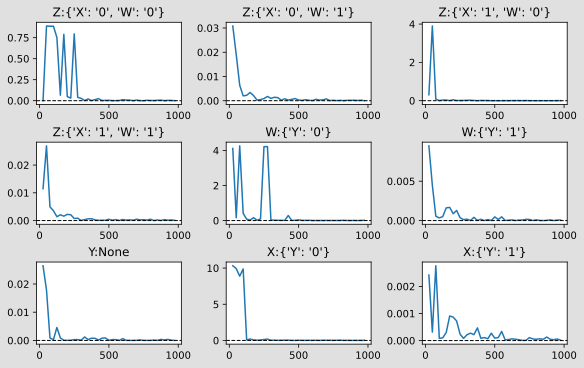

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(8, 5), constrained_layout=True)
axs_flat = axs.flatten()

ax_idx = 0

def col(vec):
    return ["green" if v > 0 else "red" for v in vec]

# For each pair of (var, parents) ...
for var, parents in confs:

    # Retrieve the results
    colname = var + ":" + str(parents)
    vec = res[colname]

    # Plot
    ax = axs_flat[ax_idx]
    ax_idx += 1

    # ax.bar(size, vec, width=5, alpha=.7, color=col(vec))
    ax.plot(size, vec)
    ax.axhline(y=0, color="black", linestyle="--", linewidth=1)
    ax.set_title(colname)
    


In [20]:
print("Number of negative values: ", np.sum(np.array(res) < 0))

Number of negative values:  0
